# Notebook 2: T1, T2 characterization and error suppression

> In this notebook, we study the relaxation time $T_1$ and the coherence times $T_2^*$ and $T_2$, which are among the most important metrics for characterizing the performance of a physical qubit. These times quantify how long a qubit can reliably store population and phase information, and they therefore set a basic limit on the fidelity of quantum operations.
>
>We will first measure $T_1$, $T_2^*$, and $T_2$ in simple noisy simulations, and then use those measurements to motivate bang-bang-style refocusing and more general dynamical decoupling sequences. This progression from characterization to suppression is useful because it connects measured device properties directly to concrete control strategies.


## 1. Introduction

On current hardware platforms, $T_1$, $T_2^*$, and $T_2$ are standard calibration quantities because they provide a first diagnosis of the dominant noise mechanisms acting on the qubit. A useful distinction is that $T_1$ describes **population relaxation**, while $T_2$ describes **loss of phase coherence**. These are related but not identical physical processes. Since quantum algorithms rely on both population and phase, both kinds of timescales matter.


### How this notebook is organized

Rather than defining all three quantities at once, we will introduce each one when it is first measured. We start with a relaxation experiment for $T_1$, then move to the Ramsey measurement of $T_2^*$, and finally use echo-based control sequences to motivate $T_2$ and dynamical decoupling.

This keeps the theory close to the experiment, so each idea appears at the point where it is actually used.

## 2. Measuring qubit relaxation and coherence

### Setup

Throughout this section, we will first demonstrate on simulators and then on real QPUs. We begin by importing the required modules from the Braket SDK. We will use the small, noisy density matrix simulator (`braket_dm`) since we only need a single qubit here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from braket.devices import LocalSimulator

from helper_functions.notebook2_helper import (
    average_p0_over_detunings,
    build_noisy_cpmg_circuit,
    build_noisy_hahn_echo_circuit,
    build_noisy_ramsey_circuit,
    build_noisy_t1_circuit,
    exp_decay,
    make_dd_real_qpu_hybrid_job,
    plot_hybrid_t2_fits,
    ramsey_decay_with_quasistatic_noise,
)

# braket_dm is the noisy simulator suitable for small circuits (up to 12 qubits)
device = LocalSimulator("braket_dm")


### Cost tracking

Amazon Braket can estimate the cost of quantum tasks created from this notebook. The tracker starts here, so later QPU tasks are included in the estimate printed near the end of the notebook.

In [2]:
from braket.tracking import Tracker

t = Tracker().start()

### Simulating idle time

Real QPUs experience decoherence during idle periods between gates. On a simulator, we model this by inserting identity gates (`I`) and attaching noise channels to them. Each identity gate represents one unit of idle time.

### Simulation of T1 measurement

A qubit is a two-level quantum system with basis states conventionally labeled $\lvert 0\rangle$ and $\lvert 1\rangle$. Usually, $\lvert 0\rangle$ is the lower-energy ground state and $\lvert 1\rangle$ is the excited state. If the qubit is prepared in $\lvert 1\rangle$, interactions with the environment cause it to relax back toward thermal equilibrium. In the low-temperature limit, this usually means decay toward $\lvert 0\rangle$. The constant that characterizes this energy decay is called the **relaxation time $T_1$**. In the simplest model, the excited-state population decays exponentially,
$$
P_1(t) \approx P_1(0)e^{-t/T_1}.
$$

This is why $T_1$ is often the first timescale one measures. It tells us how quickly the qubit loses energy, and it provides a simple first characterization of qubit quality.

The $T_1$ experiment is conceptually simple:

1. Prepare the qubit in $|1\rangle$ by applying an X gate.
2. Wait for a variable delay time $\tau$.
3. Measure the qubit in the computational basis (Z basis).

If we plot the probability of finding the qubit in $|1\rangle$ as a function of $\tau$, it decays exponentially:

$$P(|1\rangle) = e^{-\tau / T_1}$$

By fitting this decay curve, we extract $T_1$.

Now let's actually build the circuit.

In [3]:
# Gamma is the noise parameter
gamma = 0.02

# Parameters
taus = np.arange(0, 100, 5)
n_shots = 1000
p1_vals = [] # the probability of measuring |1>

# Sweep through multiple tau delays
for tau in taus:
    qc = build_noisy_t1_circuit(int(tau), gamma)
    
    # Run the circuit and extract probability of |1>
    result = device.run(qc, shots=n_shots).result()
    counts = result.measurement_counts
    p1 = counts.get("1", 0) / n_shots
    p1_vals.append(p1)

p1_vals = np.array(p1_vals)


/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/braket/default_simulator/simulator.py:336: UserWarning: You are running a noise-free circuit on the density matrix simulator. Consider running this circuit on the state vector simulator: LocalSimulator("default") for a better user experience.
  warnings.warn(


Now we fit the data to the exponential decay $A \cdot e^{-\tau / T_1}$ to extract T1.

Fitted T1: 49.04040390112977
Theoretical T1: 49.49831645250911


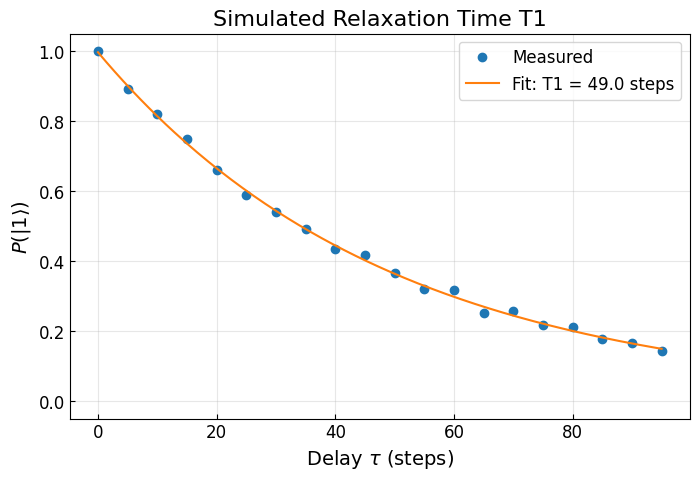

In [4]:
# Fit the T1 decay curve
popt, pcov = curve_fit(exp_decay, taus, p1_vals, p0=[1.0, 50.0, 0])
A_fit, T1_fit, C_fit = popt
print(f"Fitted T1: {T1_fit}")

# For comparison, the theoretical value is T1 = -1/ln(1 - gamma)
T1_theory = -1 / np.log(1 - gamma)
print(f"Theoretical T1: {T1_theory}")

# Plot the T1 decay
tau_fine = np.linspace(0, taus[-1], 200)

plt.figure(figsize=(8, 5))
plt.plot(taus, p1_vals, "o", color="tab:blue", label="Measured")
plt.plot(tau_fine, exp_decay(tau_fine, *popt), "-", color="tab:orange",
         label=f"Fit: T1 = {T1_fit:.1f} steps")
plt.xlabel(r"Delay $\tau$ (steps)", fontsize=14)
plt.ylabel(r"$P(|1\rangle)$", fontsize=14)
plt.title("Simulated Relaxation Time T1", fontsize=16)
plt.legend(fontsize=12)
plt.tick_params(direction="in", labelsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.show()


### Simulation of T2* measurement

To understand coherence, it is helpful to represent the qubit state $\lvert \psi \rangle$ with a density matrix,
$$
\rho = \lvert \psi \rangle \langle \psi \rvert =
\begin{pmatrix}
\rho_{00} & \rho_{01} \\
\rho_{10} & \rho_{11}
\end{pmatrix}.
$$

The diagonal terms $\rho_{00}$ and $\rho_{11}$ describe the populations in $\lvert 0\rangle$ and $\lvert 1\rangle$, while the off-diagonal terms $\rho_{01}$ and $\rho_{10}$ describe phase coherence between the two basis states. If the qubit is prepared in a superposition state such as
$$
\lvert \psi \rangle = \frac{1}{\sqrt{2}}(\lvert 0\rangle + e^{i\varphi} \lvert 1\rangle),
$$
then the relative phase $e^{i\varphi}$ between $\lvert 0\rangle$ and $\lvert 1\rangle$ is what makes the state genuinely quantum. The timescale over which this phase information is lost is called $T_2$.

Equivalently, coherence can be described on the Bloch sphere. The population difference corresponds to the $z$-component of the Bloch vector, while the phase coherence is encoded in the transverse $x$- and $y$-components. In terms of the density matrix,
$$
\langle X \rangle = 2\,\mathrm{Re}\,\rho_{01}, \qquad
\langle Y \rangle = -2\,\mathrm{Im}\,\rho_{01}.
$$
As dephasing noise randomizes the relative phase, these transverse components decay toward zero. This is why $T_2$ is often called the coherence time or dephasing time.

In practice, it is important to distinguish $T_2$ from $T_2^*$. The quantity $T_2^*$ is the **inhomogeneous dephasing time**. Since a quantum state requires many repetitive shots to read out, there is noise varying from shot to shot, such as magnetic-field drift, flux noise, or calibration drift. These fluctuations, usually slow compared to the scale of operation time, can further make qubit coherence times shorter than the intrinsic limit $T_2$. By using a refocusing pulse, one can remove much of this slow noise and recover the intrinsic $T_2$.

The T2\* experiment (also called a Ramsey experiment) measures how quickly a superposition state loses phase coherence. The protocol is:

1. Apply a Hadamard gate to create the superposition $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$.
2. Wait for a variable delay time $\tau$.
3. Apply a second Hadamard gate to interfere the $|0\rangle$ and $|1\rangle$ components.
4. Measure in the computational basis.

Without noise, the second Hadamard perfectly reverses the first, and we always measure $|0\rangle$. With dephasing, the relative phase between $|0\rangle$ and $|1\rangle$ becomes uncertain, and the probability of measuring $|0\rangle$ decays:

$$P(|0\rangle) = \frac{1}{2}\left(1 + e^{-\tau / T_2^*}\right)$$

In this notebook, we include two different sources of decoherence:

1. **Quasi-static detuning noise**: during one experimental shot, the qubit frequency is shifted by a fixed random detuning $\delta$. This produces a coherent unwanted phase accumulation. From shot to shot, $\delta$ changes, so the Ramsey signal decays after averaging many shots. This is the recoverable part of the dephasing.

2. **Markovian noise**: during each time step, we also include amplitude damping and phase damping. This represents memoryless noise. Unlike quasi-static detuning, this part cannot be perfectly undone by echo or dynamical decoupling.

This distinction is important. Ramsey decay includes both the recoverable quasi-static phase error and the irreversible Markovian dephasing. Hahn echo and dynamical decoupling can cancel the quasi-static part, so they measure a longer coherence time $T_2$ rather than the shorter $T_2^*$.


In [5]:
# Noise parameters
gamma = 0.01          # amplitude damping per step
gamma_ph = 0.02       # Markovian pure dephasing per step
sigma_delta = 0.08    # quasi-static detuning noise, rad per idle step

# Sweep parameters
taus = np.arange(0, 81, 4)
n_delta_samples = 100
shots_per_delta = 10
n_shots = n_delta_samples * shots_per_delta

rng = np.random.default_rng(seed=0)

# Run the Ramsey experiment
p0_ramsey = []  # probability of measuring |0>

for tau in taus:
    counts_0 = 0

    for _ in range(n_delta_samples):
        # One random detuning per experimental shot group.
        # Within that shot group, the detuning is quasi-static.
        delta = rng.normal(loc=0.0, scale=sigma_delta)

        qc = build_noisy_ramsey_circuit(int(tau), gamma, gamma_ph, delta)
        result = device.run(qc, shots=shots_per_delta).result()
        counts = result.measurement_counts

        counts_0 += counts.get("0", 0)

    p0_ramsey.append(counts_0 / n_shots)

p0_ramsey = np.array(p0_ramsey)

# print(p0_ramsey)


In [6]:
# Fit the Ramsey curve
popt_ramsey, _ = curve_fit(
    ramsey_decay_with_quasistatic_noise,
    taus,
    p0_ramsey,
    p0=[1.0, 50.0, 20.0],
    bounds=([0.0, 1e-6, 1e-6], [1.0, np.inf, np.inf])
)

A_fit, T2_markovian_fit, T2_star_fit = popt_ramsey

print(f"Fitted contrast A = {A_fit:.3f}")
print(f"Fitted Markovian T2 = {T2_markovian_fit:.2f} steps")
print(f"Fitted quasi-static T2* = {T2_star_fit:.2f} steps")

Fitted contrast A = 1.000
Fitted Markovian T2 = 53.26 steps
Fitted quasi-static T2* = 18.18 steps


<div class="alert alert-block alert-success">
<b>Activity:</b> Try changing the quasi-static detuning strength <code>sigma_delta</code> and the Markovian damping probabilities <code>gamma, gamma_ph</code>. Which part of the Ramsey decay can be recovered by echo, and which part remains?
</div>


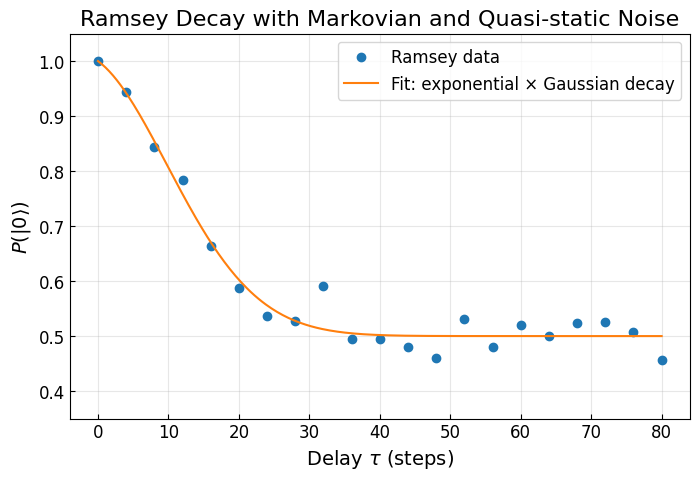

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(taus, p0_ramsey, "o", label="Ramsey data")

t_fit = np.linspace(min(taus), max(taus), 300)
plt.plot(
    t_fit,
    ramsey_decay_with_quasistatic_noise(t_fit, *popt_ramsey),
    "-",
    label="Fit: exponential × Gaussian decay"
)

plt.xlabel(r"Delay $\tau$ (steps)", fontsize=14)
plt.ylabel(r"$P(|0\rangle)$", fontsize=14)
plt.title("Ramsey Decay with Markovian and Quasi-static Noise", fontsize=16)
plt.legend(fontsize=12)
plt.tick_params(direction="in", labelsize=12)
plt.ylim(0.35, 1.05)
plt.grid(alpha=0.3)
plt.show()

The probability of measuring $|0\rangle$ starts near 1 and decays toward 0.5 as phase coherence is lost. In this simulation, the Ramsey decay has two contributions. The quasi-static detuning noise creates a shot-to-shot phase spread, while the Markovian phase damping produces irreversible loss of coherence during the sequence.

This is why $T_2^*$ is usually shorter than the echo-based $T_2$. Ramsey is sensitive to slow frequency offsets as well as true dephasing. Echo and dynamical decoupling can refocus the slow detuning part, but they cannot perfectly remove Markovian noise.

The relation between relaxation and coherence is commonly written as
$$
\frac{1}{T_2} = \frac{1}{2T_1} + \frac{1}{T_\phi},
$$
where $T_\phi$ is the pure-dephasing time. The term $1/(2T_1)$ comes from energy relaxation itself, while $1/T_\phi$ comes from phase randomization that does not involve energy exchange. Since $1/T_\phi \ge 0$, this implies the standard bound
$$
T_2 \le 2T_1.
$$
If a qubit operates close to the limit $T_2 = 2T_1$, it is said to be **$T_1$-limited**, meaning that pure dephasing is already small and further improvements in coherence require improving relaxation itself.


## 3. Bang-bang control and dynamical decoupling

The idea behind dynamical decoupling is older than quantum computing. It began in magnetic resonance. In 1950, Erwin Hahn discovered the **spin echo**: an ensemble of spins that seemed to have dephased could be made to rephase by applying a refocusing pulse. The result was surprising and beautiful: the lost signal was not truly gone. Part of it was hidden in reversible phase evolution.

A few years later, Carr and Purcell extended this idea by repeating refocusing pulses, and Meiboom and Gill refined the sequence into what is now called **CPMG**. These techniques became everyday tools in NMR, MRI, and electron-spin resonance because they separate irreversible relaxation from phase spreading caused by slow field inhomogeneity.

Quantum computing inherited this language directly. In the late 1990s, dynamical decoupling was recast as a quantum-control method: if the environment is slow enough, fast pulses can average away part of the unwanted qubit-environment interaction.

Let's first look at Hahn echo. The sequence is

$$
\frac{\pi}{2} - \tau - \pi - \tau - \frac{\pi}{2} .
$$

The first $\pi/2$ pulse prepares the qubit on the equator. During the first waiting time, different detunings make different shots fan out in phase. The $\pi$ pulse flips the sign of the accumulated phase. During the second waiting time, a quasi-static detuning makes the phases retrace and refocus.

The four Bloch spheres below show this idea for two representative shots with opposite detunings.

![dynamical decoupling](figures/notebooks/dynamical_decoupling.png)

In [8]:
# Noise parameters are the same as the Ramsey section.
gamma = 0.01
gamma_ph = 0.02
sigma_delta = 0.08

# Sweep total free-precession time.
taus_dd = np.arange(0, 81, 8)
n_detuning_samples = 80
rng = np.random.default_rng(seed=0)
detuning_samples = rng.normal(
    loc=0.0,
    scale=sigma_delta,
    size=(len(taus_dd), n_detuning_samples),
)

p0_echo_detuning = average_p0_over_detunings(
    lambda tau, delta: build_noisy_hahn_echo_circuit(tau, gamma, gamma_ph, delta),
    taus_dd,
    detuning_samples,
)

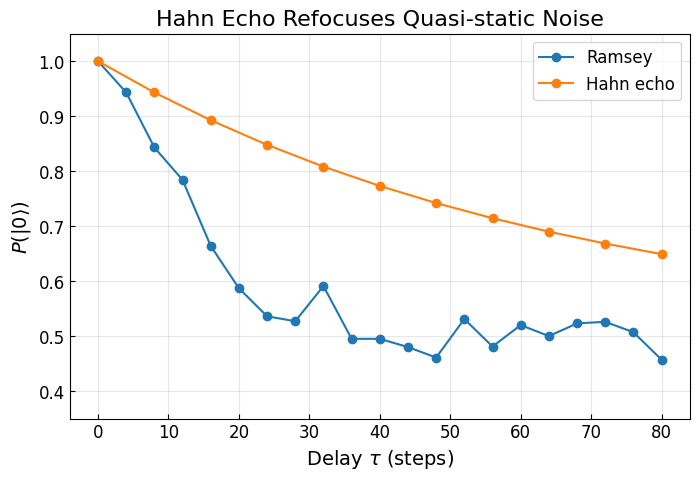

In [9]:
plt.figure(figsize=(8, 5))

taus_ramsey = np.arange(0, 81, 4)
plt.plot(taus_ramsey, p0_ramsey, "o-", label="Ramsey")
plt.plot(taus_dd, p0_echo_detuning, "o-", label="Hahn echo")

plt.xlabel(r"Delay $\tau$ (steps)", fontsize=14)
plt.ylabel(r"$P(|0\rangle)$", fontsize=14)
plt.title("Hahn Echo Refocuses Quasi-static Noise", fontsize=16)
plt.legend(fontsize=12)
plt.tick_params(direction="in", labelsize=12)
plt.ylim(0.35, 1.05)
plt.grid(alpha=0.3)
plt.show()

### CPMG4: repeated refocusing

Hahn echo uses one refocusing pulse. CPMG repeats the same idea: insert several $\pi$ pulses during the free-precession time so the sign of the phase error is flipped back and forth. Here we use CPMG4, meaning four evenly spaced $X$ pulses with half-size waiting periods at the beginning and end,

$$
\frac{\pi}{2} - \frac{\tau}{8} - X - \frac{\tau}{4} - X - \frac{\tau}{4} - X - \frac{\tau}{4} - X - \frac{\tau}{8} - \frac{\pi}{2} .
$$

For perfectly quasi-static detuning, Hahn echo already cancels most of the recoverable phase error. CPMG4 is more useful when the noise changes slowly during the experiment, because more frequent flips reduce the time over which phase errors can build up.

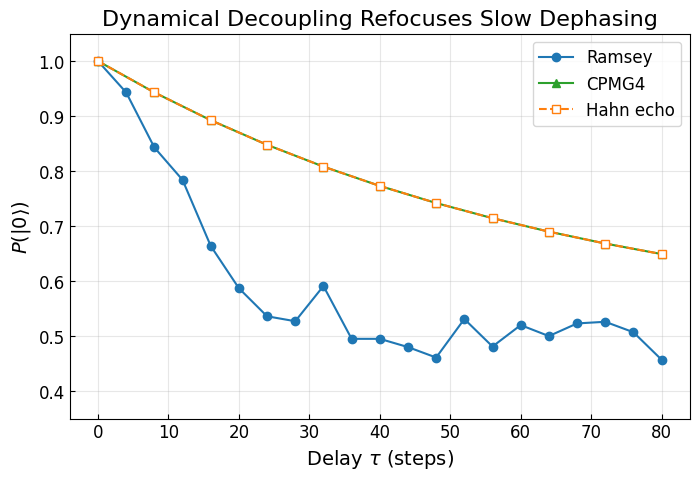

In [10]:
p0_cpmg4_detuning = average_p0_over_detunings(
    lambda tau, delta: build_noisy_cpmg_circuit(tau, gamma, gamma_ph, delta, n_pulses=4),
    taus_dd,
    detuning_samples,
)

plt.figure(figsize=(8, 5))
plt.plot(taus_ramsey, p0_ramsey, "o-", label="Ramsey")
plt.plot(taus_dd, p0_cpmg4_detuning, "^-", color="tab:green", label="CPMG4")
plt.plot(
    taus_dd,
    p0_echo_detuning,
    "s--",
    color="tab:orange",
    markerfacecolor="white",
    label="Hahn echo",
)

plt.xlabel(r"Delay $\tau$ (steps)", fontsize=14)
plt.ylabel(r"$P(|0\rangle)$", fontsize=14)
plt.title("Dynamical Decoupling Refocuses Slow Dephasing", fontsize=16)
plt.legend(fontsize=12)
plt.tick_params(direction="in", labelsize=12)
plt.ylim(0.35, 1.05)
plt.grid(alpha=0.3)
plt.show()

Ramsey decays because each shot sees a different detuning and accumulates a different phase. Averaging over many shots reduces the measured contrast.

Hahn echo cancels the part of the phase error that is approximately constant during one shot. The Markovian damping terms are still present, so the signal is not perfectly protected.

CPMG4 repeats the refocusing idea with four $\pi$ pulses. In this quasi-static model it behaves similarly to Hahn echo, because one echo pulse already cancels the slow detuning. In real devices, multi-pulse dynamical decoupling can help more when the noise varies slowly but not perfectly statically during the experiment.

### How DD is used in current quantum-computing systems

In commercial quantum processors, dynamical decoupling is usually used as error suppression during idle time. Real circuits contain gaps: one qubit may wait while another qubit is being measured, routed, or involved in a two-qubit gate. During those gaps, the idle qubit can pick up phase noise or unwanted coupling to neighboring qubits. DD inserts carefully timed pulses into those idle windows to keep the qubit from drifting too far.

On superconducting platforms, this often appears as compiler- or scheduler-level pulse insertion after the circuit has been mapped to hardware timings. For example, cloud systems can add sequences such as Hahn echo, CPMG, XY4, or related variants to reduce dephasing and crosstalk. On pulse-enabled services such as Amazon Braket Pulse, researchers can also build these sequences explicitly, which is what the real-QPU section below is trying to do.

The important caveat is that DD is not magic and not full quantum error correction. It helps most when the noise is slow compared with the pulse spacing. It cannot remove energy relaxation ($T_1$ decay), and too many pulses can make things worse if the pulses themselves have errors.

## 4. Running dynamical decoupling on a real QPU

The simulator above used ideal gates plus a simple noise model. On a real QPU, the waiting time is a physical idle period, so we use Amazon Braket pulse control to insert calibrated delays between gates.

This section compares three coherence experiments on hardware:

1. Ramsey: $H - \tau - H$.
2. Hahn echo: $H - \tau/2 - X - \tau/2 - H$.
3. CPMG4: four evenly spaced $X$ refocusing pulses during the same total time $\tau$.

The final $H$ pulse maps the remaining phase coherence back into the computational basis. A larger $P(|0\rangle)$ means more coherence survived the sequence.

We use the direct QPU workflow first because it is the most reliable path for a short experiment. The optional Hybrid Jobs workflow appears afterward; it is useful when you need managed execution or priority task queuing, but the hybrid job itself can wait in a separate job queue before any QPU tasks are created.

### Hardware parameters

The parameters below control the target device, physical qubit, number of shots, and evolution times. The same values are reused by both the direct QPU path and the Hybrid Jobs path.

In [5]:
from braket.aws import AwsDevice

# qpu_arn = "arn:aws:braket:us-west-1::device/qpu/rigetti/Ankaa-3"
qpu_arn = "arn:aws:braket:us-west-1::device/qpu/rigetti/Cepheus-1-108Q"

qubit = 0
shots = 1000
evolution_times_us = np.arange(2, 50, 2)
num_cpmg_pulses = 4
time_grid = 4e-9

# Hybrid Jobs need an IAM role. This is only used in the optional Hybrid Jobs section.
job_role_arn = "arn:aws:iam::338348453266:role/service-role/AmazonBraketJobsExecutionRole"

# Notebook 1 creates this bucket for project data.
data_bucket_name = "amazon-braket-batch-project-338348453266-us-east-1"
direct_s3_prefix = "qubit_t1_t2_characterization/dd_real_qpu"
hybrid_s3_prefix = "qubit_t1_t2_characterization/dd_real_qpu_hybrid_job"


### Connect to the QPU

This cell creates the `AwsDevice` object and prints basic information about the target. 

In [6]:
qpu = AwsDevice(qpu_arn)
direct_s3_folder = (data_bucket_name, direct_s3_prefix)

print(f"Target QPU: {qpu.name}")
print(f"Device ARN: {qpu_arn}")
print(f"Device status: {qpu.status}")
print(f"Direct QPU results will be stored in s3://{direct_s3_folder[0]}/{direct_s3_folder[1]}")

Target QPU: Cepheus-1-108Q
Device ARN: arn:aws:braket:us-west-1::device/qpu/rigetti/Cepheus-1-108Q
Device status: ONLINE
Direct QPU results will be stored in s3://amazon-braket-batch-project-338348453266-us-east-1/qubit_t1_t2_characterization/dd_real_qpu


### Run circuit as a Hybrid Job

Hybrid Jobs run the experiment inside a managed AWS container. Once the job starts, the QPU tasks submitted from inside it can access the hybrid-job priority queue. This can reduce waiting time between tasks and helps the circuits run under a more consistent device environment. 

The function below repeats the circuit construction inside the job. This is intentional because the job runs in a separate container and should include all code needed to build and submit the circuits.

### Define the Hybrid Job

We use the `qpu_arn` and `job_role_arn` to make a Hybrid Job.

In [7]:
dd_real_qpu_hybrid_job = make_dd_real_qpu_hybrid_job(qpu_arn, job_role_arn)


### Submit the Hybrid Job

This creates one Hybrid Job. The job will submit all Ramsey, Hahn echo, and CPMG4 tasks from inside the managed AWS container. 

In [8]:
evolution_times_us_csv = ",".join(str(int(time_us)) for time_us in evolution_times_us)

dd_job = dd_real_qpu_hybrid_job(
    qubit=qubit,
    shots=shots,
    evolution_times_us_csv=evolution_times_us_csv,
    num_cpmg_pulses=num_cpmg_pulses,
    data_bucket_name=data_bucket_name,
    s3_prefix=hybrid_s3_prefix,
)

print(dd_job)

AwsQuantumJob('arn':'arn:aws:braket:us-west-1:338348453266:job/2ad94b80-6ec6-4f5c-8de4-9771a2f5e78f')


### Monitor the Hybrid Jobs

Print out all the Hybrid Jobs and their status. If the job stays in `QUEUED` with zero QPU tasks, it is waiting in the Hybrid Jobs queue and your Python code has not started yet.

In [11]:
import boto3

region = "us-west-1"
device_arn = "arn:aws:braket:us-west-1::device/qpu/rigetti/Cepheus-1-108Q"

braket_client = boto3.client("braket", region_name=region)

response = braket_client.search_jobs(
    filters=[],
    maxResults=20
)

jobs = response["jobs"]

for i, job in enumerate(jobs):
    print(f"\n[{i}]")
    print("Job name:", job.get("jobName"))
    print("Status:  ", job.get("status"))
    print("Device:  ", job.get("device"))
    print("Job ARN: ", job.get("jobArn"))
    print("Created: ", job.get("createdAt"))


# Run the following line if need to cancel any of the jobs
# response = braket_client.cancel_job(jobArn="your job arn")


[0]
Job name: dd-real-qpu-hybrid-job-1780868069274
Status:   COMPLETED
Device:   arn:aws:braket:us-west-1::device/qpu/rigetti/Cepheus-1-108Q
Job ARN:  arn:aws:braket:us-west-1:338348453266:job/2ad94b80-6ec6-4f5c-8de4-9771a2f5e78f
Created:  2026-06-07 21:34:36.958000+00:00

[1]
Job name: dd-real-qpu-hybrid-job-1780862649502
Status:   COMPLETED
Device:   arn:aws:braket:us-west-1::device/qpu/rigetti/Cepheus-1-108Q
Job ARN:  arn:aws:braket:us-west-1:338348453266:job/2a67a710-88a3-4ae3-8a17-52cd12d3ad33
Created:  2026-06-07 20:04:15.636000+00:00

[2]
Job name: dd-real-qpu-hybrid-job-1780860026208
Status:   CANCELLED
Device:   arn:aws:braket:us-west-1::device/qpu/rigetti/Cepheus-1-108Q
Job ARN:  arn:aws:braket:us-west-1:338348453266:job/06ea3c04-694a-4ca3-838f-0686d2f3372e
Created:  2026-06-07 19:20:29.953000+00:00

[3]
Job name: dd-real-qpu-hybrid-job-1780859974225
Status:   CANCELLED
Device:   arn:aws:braket:us-west-1::device/qpu/rigetti/Cepheus-1-108Q
Job ARN:  arn:aws:braket:us-west-1:3

### Extract Hybrid Job results

Only run this cell after the monitor cell reports `COMPLETED`. If the job is still queued or running, this cell prints a message instead of blocking indefinitely.

In [12]:
from braket.aws import AwsQuantumJob

# To recover quantum task, paste the job arn here
# dd_job_arn = "arn:aws:braket:us-west-1:338348453266:job/2a67a710-88a3-4ae3-8a17-52cd12d3ad33"
dd_job_arn = "arn:aws:braket:us-west-1:338348453266:job/2ad94b80-6ec6-4f5c-8de4-9771a2f5e78f"

# Reconstruct the Hybrid Job object
dd_job = AwsQuantumJob(arn=dd_job_arn)

# Check status
status = dd_job.state(use_cached_value=False)

if dd_job.state(use_cached_value=False) != "COMPLETED":
    print("Hybrid job is not completed yet. Run the monitor cell again later.")
else:
    dd_job_result = dd_job.result(allow_pickle=True)

    p0_qpu_hybrid = dd_job_result["p0_qpu"]
    task_ids_by_sequence_hybrid = dd_job_result["task_ids_by_sequence"]
    evolution_times_us_hybrid = np.array(dd_job_result["evolution_times_us"])

    for sequence_name, p0_values in p0_qpu_hybrid.items():
        for evolution_time_us, p0 in zip(evolution_times_us_hybrid, p0_values):
            print(
                f"{sequence_name:9s} tau = {evolution_time_us:>4g} us: "
                f"P(|0>) = {p0:.3f}"
            )

    print("\nTask IDs by sequence:")
    for sequence_name, task_ids in task_ids_by_sequence_hybrid.items():
        print(sequence_name, task_ids)

Ramsey    tau =    2 us: P(|0>) = 0.843
Ramsey    tau =    4 us: P(|0>) = 0.625
Ramsey    tau =    6 us: P(|0>) = 0.369
Ramsey    tau =    8 us: P(|0>) = 0.276
Ramsey    tau =   10 us: P(|0>) = 0.212
Ramsey    tau =   12 us: P(|0>) = 0.283
Ramsey    tau =   14 us: P(|0>) = 0.462
Ramsey    tau =   16 us: P(|0>) = 0.578
Ramsey    tau =   18 us: P(|0>) = 0.685
Ramsey    tau =   20 us: P(|0>) = 0.715
Ramsey    tau =   22 us: P(|0>) = 0.671
Ramsey    tau =   24 us: P(|0>) = 0.583
Ramsey    tau =   26 us: P(|0>) = 0.487
Ramsey    tau =   28 us: P(|0>) = 0.414
Ramsey    tau =   30 us: P(|0>) = 0.373
Ramsey    tau =   32 us: P(|0>) = 0.427
Ramsey    tau =   34 us: P(|0>) = 0.447
Ramsey    tau =   36 us: P(|0>) = 0.536
Ramsey    tau =   38 us: P(|0>) = 0.573
Ramsey    tau =   40 us: P(|0>) = 0.566
Ramsey    tau =   42 us: P(|0>) = 0.591
Ramsey    tau =   44 us: P(|0>) = 0.563
Ramsey    tau =   46 us: P(|0>) = 0.507
Ramsey    tau =   48 us: P(|0>) = 0.470
Hahn echo tau =    2 us: P(|0>) = 0.949


### Plot Hybrid Job results

This plot uses the results returned by the Hybrid Job. If you skipped the Hybrid Jobs path, use the direct QPU plot above instead.

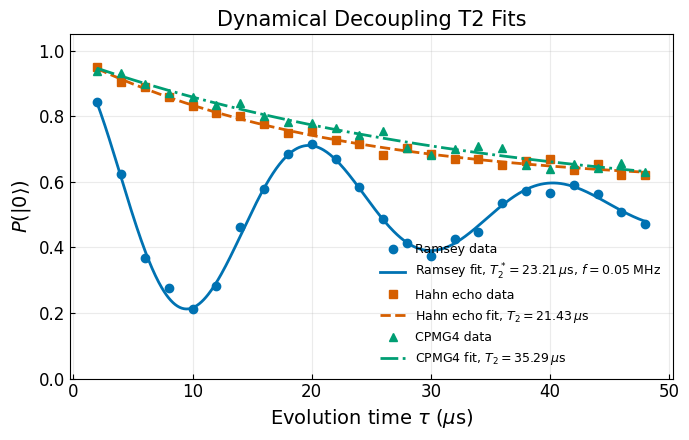

{'Ramsey': {'p_inf': np.float64(0.5158823515968666),
  'A': np.float64(0.46160595734861926),
  'T2star_us': np.float64(23.208089326308375),
  'T2star_err_us': np.float64(1.2537570278776462),
  'f_det_MHz': np.float64(0.048813181512661806),
  'f_det_err_MHz': np.float64(0.0003347317813646321),
  'phi_rad': np.float64(0.08801836940454195)},
 'Hahn echo': {'p_inf': np.float64(0.5876499559088534),
  'A': np.float64(0.39259492410036495),
  'T2_us': np.float64(21.432423216497522),
  'T2_err_us': np.float64(1.8877867824009116)},
 'CPMG4': {'p_inf': np.float64(0.5142861856866494),
  'A': np.float64(0.4573386489505618),
  'T2_us': np.float64(35.286004742071704),
  'T2_err_us': np.float64(6.671853170576184)}}

In [13]:
fit_results = plot_hybrid_t2_fits(evolution_times_us_hybrid, p0_qpu_hybrid)
fit_results


Our extracted $T_2$ is close to the reported value for qubit 0. Although $T_2^*$ appears to be slightly longer than $T_2$, this difference is within the measurement and fitting uncertainty. CPMG4 gives a slightly longer coherence time than Hahn echo, but the improvement is not large. This suggests that quasi-static noise may not be the dominant decoherence channel here. 

To investigate this further, we could measure $T_1$ on the same qubit to check whether the coherence is relaxation-limited, run CPMG sequences with more refocusing pulses to see whether coherence continues to improve, and repeat the measurements over time to check whether calibration drift or device fluctuations affect the extracted values.

### Cost estimate

The tracker reports estimated Braket quantum-task charges for tasks created from this notebook session. Estimates can differ from final AWS billing and may not include all managed compute charges associated with Hybrid Jobs.

In [22]:
if "t" not in globals():
    print("Run the cost tracking setup cell near the top of the notebook first.")
else:
    print(
        "Note: Charges shown are estimates based on Amazon Braket simulator and QPU task usage. "
        "Estimated charges may differ from actual AWS billing and do not include every possible "
        "charge, such as managed compute used by Hybrid Jobs."
    )
    print(
        f"Estimated cost to run tracked Braket tasks: "
        f"{t.qpu_tasks_cost() + t.simulator_tasks_cost():.2f} USD"
    )

Note: Charges shown are estimates based on Amazon Braket simulator and QPU task usage. Estimated charges may differ from actual AWS billing and do not include every possible charge, such as managed compute used by Hybrid Jobs.
Estimated cost to run tracked Braket tasks: 0.00 USD


In [2]:
!ls ..

'Braket algorithms'   afqmc-tutorial-main       lab1.ipynb
'Braket examples'     afqmc-tutorial-main.zip   lost+found
 Project	      bell_sv1_result.json
